# Infant Cry Language Detection – Introduction & Goals

## 📌 Introduction
Babies cry to communicate their needs, but they cannot explain the reason in words.  
For parents, especially new or busy ones, it can be challenging to understand:
- Is the baby *hungry*?
- Is the baby *in pain*?
- Does the baby *need a diaper change*?
- Is the baby *uncomfortable or sleepy*?

In this project, we will use *Machine Learning* and *Deep Learning* to classify infant cries into meaningful categories based on audio recordings.

---

## 🎯 Project Goals
1. *Detect and classify baby cries* into specific needs (e.g., hunger, pain, discomfort, etc.).
2. Build a *TensorFlow-based model* that can be deployed on web/mobile apps.
3. Create a *clean, step-by-step workflow* from raw audio data to model deployment.
4. Ensure the model is robust to:
   - Background noise
   - Different recording devices
   - Variations between babies
5. Prepare the groundwork for *future health-related features*, such as:
   - Asking follow-up questions after detecting certain cry types
   - Suggesting possible health conditions

---

## ✅ Success Criteria
- Model achieves *at least 80% accuracy* on a held-out test set.
- Model inference time is *fast enough* for real-time use.
- Code is *reproducible and ready for deployment*.

---

## 📂 Dataset
We will use a dataset containing labeled baby cry audio files, each belonging to one of several categories (e.g., hunger, pain, discomfort).  
We will preprocess these audio clips into features (MFCC, Mel-spectrograms) before feeding them into the model.


# Core libraries


In [1]:


import numpy as np
# NumPy: Used for fast numerical computations, arrays, and mathematical operations.

import pandas as pd
import glob
# Pandas: For loading, cleaning, and manipulating datasets (e.g., CSV files).

# --------------------------
# Visualization libraries
# --------------------------

import matplotlib.pyplot as plt
# Matplotlib: Base Python plotting library to create graphs and visualizations.

import seaborn as sns
# Seaborn: Built on Matplotlib; makes creating beautiful, statistical visualizations easier.

# --------------------------
# Machine learning tools
# --------------------------

from sklearn.model_selection import train_test_split
# Splits data into training and testing sets for model evaluation.

from sklearn.preprocessing import LabelEncoder
# Converts text labels (e.g., 'cry', 'noise') into numeric form for ML models.

from sklearn.metrics import classification_report, confusion_matrix
# classification_report: Gives precision, recall, and F1-score.
# confusion_matrix: Shows correct and incorrect predictions.

# --------------------------
# Audio processing libraries
# --------------------------

import librosa
# Librosa: For loading audio files, extracting features (like MFCCs) for ML.

import librosa.display
# Part of Librosa: Displays waveforms, spectrograms, etc.

import soundfile as sf
# SoundFile: Reads and writes sound files (WAV, FLAC, etc.).

# --------------------------
# Deep learning (TensorFlow & Keras)
# --------------------------

import tensorflow as tf
# TensorFlow: Google’s deep learning library, used for training neural networks.

from tensorflow.keras.models import Sequential
# Sequential: Simplest way to build a neural network layer-by-layer.

from tensorflow.keras.layers import Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten
# Dense: Fully connected layer in neural networks.
# Dropout: Prevents overfitting by randomly turning off neurons during training.
# LSTM: Long Short-Term Memory layer for sequence/audio data.
# Conv1D: 1D Convolution layer for extracting patterns from sequences.
# MaxPooling1D: Reduces sequence length, keeps important features.
# Flatten: Converts multi-dimensional data into 1D for Dense layers.

# --------------------------
# Warnings control
# --------------------------

import warnings
warnings.filterwarnings('ignore')
# Suppresses unnecessary warning messages in the output.

# 2.Project Configuration

In [2]:

import os

# Path to dataset
DATASET_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset"

# Audio settings
SAMPLE_RATE = 22050  # Common for speech/cry processing
CLIP_DURATION = 5.0  # In seconds
SAMPLES_PER_CLIP = int(SAMPLE_RATE * CLIP_DURATION)

# Label map: maps folder names to numeric labels
LABEL_MAP = {
    "belly_pain": 0,
    "burping": 1,
    "cold_hot": 2,
    "discomfort": 3,
    "hungry": 4,
    "laugh": 5,
    "lonely": 6,
    "noise": 7,
    "scared": 8,
    "silence": 9,
    "tired": 10
}

# Reverse label map (for predictions -> human readable)
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

# Verify dataset structure
print("Dataset Path:", DATASET_PATH)
print("Subfolders:", os.listdir(DATASET_PATH))
print("Number of Classes:", len(LABEL_MAP))

Dataset Path: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset
Subfolders: ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'laugh', 'lonely', 'noise', 'scared', 'silence', 'tired']
Number of Classes: 11


In [3]:
import os
from pydub import AudioSegment

# Paths
DATASET_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset"
DATASET_WAV_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV"

# Make sure WAV directory exists
os.makedirs(DATASET_WAV_PATH, exist_ok=True)

# Loop through all class folders
for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_path):
        continue
    
    # Make matching folder in WAV dataset
    wav_class_path = os.path.join(DATASET_WAV_PATH, class_name)
    os.makedirs(wav_class_path, exist_ok=True)
    
    # Loop through all audio files
    for file in os.listdir(class_path):
        file_path = os.path.join(class_path, file)
        if not os.path.isfile(file_path):
            continue
        
        # Create new .wav filename
        base_name = os.path.splitext(file)[0] + ".wav"
        wav_file_path = os.path.join(wav_class_path, base_name)
        
        try:
            # Load and convert
            audio = AudioSegment.from_file(file_path)
            audio.export(wav_file_path, format="wav")
            print(f"Converted: {file} -> {wav_file_path}")
        except Exception as e:
            print(f"❌ Error converting {file_path}: {e}")

Converted: 357c.wav -> C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\357c.wav
Converted: 358c.wav -> C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\358c.wav
Converted: 359c.wav -> C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\359c.wav
Converted: 360c.wav -> C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\360c.wav
Converted: 361c.wav -> C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\361c.wav
Converted: 362c.wav -> C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\362c.wav
Converted: 363c.wav -> C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\363c.wav
Converted: 364c.wav -> C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\364c.wav
Converted: 365c.wav -> C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\365c.wav
Converted: 366c.wav -> C:\Users\Hussein\Desktop\baby_cr

# Step 4: Data Loading



In [4]:

import glob


# Use the WAV dataset folder
DATASET_WAV_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV"

# Create a list to store file paths and labels
data_records = []

# Loop over each class folder using LABEL_MAP from Step 3
for label_name, label_id in LABEL_MAP.items():
    folder_path = os.path.join(DATASET_WAV_PATH, label_name)
    if not os.path.exists(folder_path):
        print(f"Warning: Folder '{folder_path}' not found.")
        continue
    
    # Get all audio files (WAV format)
    wav_files = glob.glob(os.path.join(folder_path, "*.wav"))
    if not wav_files:
        print(f"⚠ No WAV files found in: {folder_path}")
        continue
    
    for file_path in wav_files:
        data_records.append({
            "file_path": file_path,
            "label": label_id,
            "label_name": label_name
        })
    
    print(f"✅ {label_name}: {len(wav_files)} files")

# Convert list to DataFrame
df = pd.DataFrame(data_records)

# Display summary
print(f"\n✅ Total audio files loaded: {len(df)}")
print(f"✅ Number of classes: {df['label_name'].nunique()}")
print("\nSample data:")
print(df.sample(5))

✅ belly_pain: 133 files
✅ burping: 124 files
✅ cold_hot: 130 files
✅ discomfort: 142 files
✅ hungry: 397 files
✅ laugh: 108 files
✅ lonely: 25 files
✅ noise: 108 files
✅ scared: 33 files
✅ silence: 108 files
✅ tired: 142 files

✅ Total audio files loaded: 1450
✅ Number of classes: 11

Sample data:
                                              file_path  label  label_name
973   C:\Users\Hussein\Desktop\baby_cries_language\B...      5       laugh
585   C:\Users\Hussein\Desktop\baby_cries_language\B...      4      hungry
508   C:\Users\Hussein\Desktop\baby_cries_language\B...      3  discomfort
1107  C:\Users\Hussein\Desktop\baby_cries_language\B...      7       noise
759   C:\Users\Hussein\Desktop\baby_cries_language\B...      4      hungry


In [18]:
# for label_name, label_id in LABEL_MAP.items():
#     folder_path = os.path.join(DATASET_WAV_PATH, label_name)
    
#     if not os.path.exists(folder_path):
#         print(f"❌ Missing folder: {label_name}")
#         continue
    
#     wav_files = glob.glob(os.path.join(folder_path, "*.wav"))
    
#     if not wav_files:
#         print(f"⚠ No WAV files found in: {label_name}")
#     else:
#         print(f"✅ {label_name}: {len(wav_files)} files")

# Step 5: Data Visualization

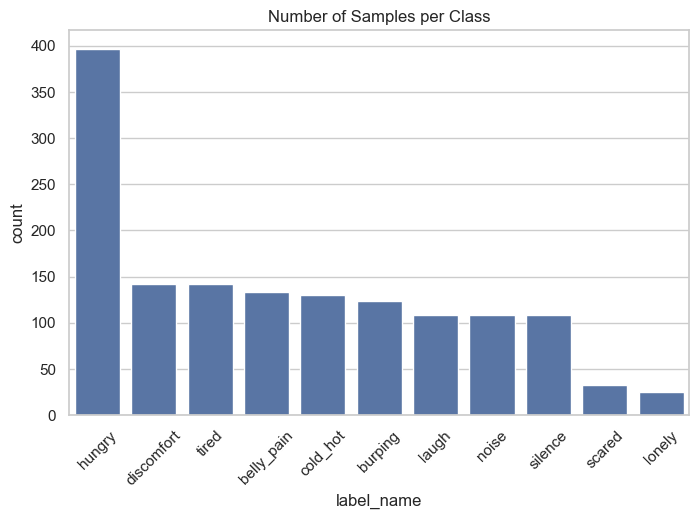

⏳ Calculating durations...


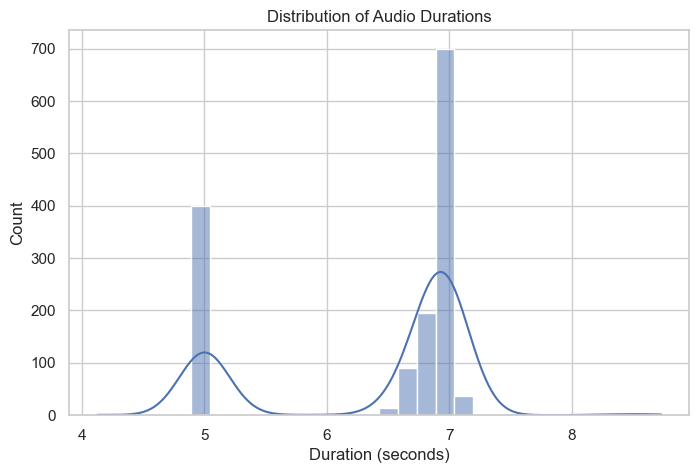

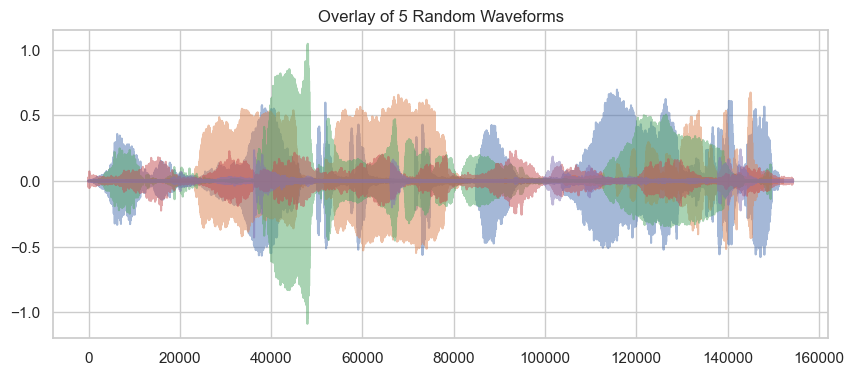

✅ EDA Completed.


In [5]:
# --------------------------

# --------------------------



# Set style
sns.set(style="whitegrid")

def explore_audio_dataset(df, sample_rate=22050, index=None):
    """
    Performs full EDA on the audio dataset:
    - Class distribution
    - Duration distribution
    - RMS energy
    - Zero Crossing Rate
    - Chroma
    - Waveform, Spectrogram, MFCC for selected index
    
    Parameters:
    - df: DataFrame with 'file_path' and 'label_name'
    - sample_rate: Sampling rate for librosa.load
    - index: If given, plots detailed features for that file
    """
    
    # 1. Class distribution
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x='label_name', order=df['label_name'].value_counts().index)
    plt.xticks(rotation=45)
    plt.title("Number of Samples per Class")
    plt.show()

    # 2. Duration distribution
    print("⏳ Calculating durations...")
    df['duration_sec'] = df['file_path'].apply(lambda fp: librosa.get_duration(filename=fp))
    plt.figure(figsize=(8,5))
    sns.histplot(df['duration_sec'], bins=30, kde=True)
    plt.xlabel("Duration (seconds)")
    plt.title("Distribution of Audio Durations")
    plt.show()

    # 3. Multi-file waveform overlay (5 random samples)
    plt.figure(figsize=(10,4))
    for path in df['file_path'].sample(min(5, len(df))):
        y, _ = librosa.load(path, sr=sample_rate)
        plt.plot(y, alpha=0.5)
    plt.title("Overlay of 5 Random Waveforms")
    plt.show()

    # 4. If index provided, show detailed plots for that file
    if index is not None:
        if index < 0 or index >= len(df):
            print(f"⚠ Index {index} is out of range (0 to {len(df)-1}).")
            return
        
        file_path = df['file_path'].iloc[index]
        label_name = df['label_name'].iloc[index]
        print(f"🎯 Detailed Analysis for index={index}, label={label_name}")
        
        y, sr = librosa.load(file_path, sr=sample_rate)
        
        
    print("✅ EDA Completed.")

# Example usage:
# Full dataset EDA
explore_audio_dataset(df, sample_rate=22050)

# EDA + detailed file view
# explore_audio_dataset(df, sample_rate=22050, index=7)

# 📊 Dataset Analysis Overview

---

## 1️⃣ Class Distribution (Bar Plot)

*What it shows:*  
How many samples exist for each emotion/class in your dataset.

*Example from your graph:*  
- *Hungry* is the largest category (~400 samples)  
- *Lonely* has very few samples (<20)  

*Effect:*  
This reveals *class imbalance*.  
Models trained on imbalanced datasets tend to perform well on majority classes and poorly on minority ones.  
➡ In our case, "hungry" might dominate training accuracy, but "lonely" could be hard for the model to detect.

*What to do:*  
- *Option 1:* Collect more samples for underrepresented classes.  
- *Option 2:* Use data augmentation (pitch shifting, time stretching, adding noise) for minority classes.  
- *Option 3:* Use *class weights* in our model’s loss function so rare classes are given more importance.  

---

## 2️⃣ Duration Distribution (Histogram + KDE)

*What it shows:*  
The spread of audio durations across our dataset.  
Looks like most files are around *5 seconds*, with a few slightly longer or shorter.

*Effect:*  
Large variation in duration can cause *inconsistent input sizes* for the model.  
- Very short files might lose info after padding.  
- Very long files might be cut off.

*What to do:*  
Decide on a fixed duration for all audio (e.g., *5 seconds*) and either:  
- Trim longer files  
- Pad shorter ones with silence  
OR  
- Use variable-length input methods (advanced: recurrent models that handle varying time steps)  

---

## 3️⃣ Overlay of Random Waveforms 

*What it shows:*  
A few randomly selected audio waveforms overlaid.  
we can see:  
- Amplitude differences (loudness)  
- Patterns in sound events (bursts of energy)

*Effect:*  
May reveal *amplitude imbalance*:  
- Some recordings are very quiet, others loud.  
- The model may learn more from volume than from actual sound patterns → *bad*.

*What to do:*  
Apply *volume normalization* so all audio is roughly the same loudness before feature extraction.  
- Especially important before converting to *spectrograms* or *MFCCs*.  

---

✅

In [6]:
def check_data_quality(df, sample_rate=22050):
    issues = {
        "missing_files": [],
        "corrupted_files": [],
        "duplicates": [],
        "outliers": []
    }
    
    seen_hashes = set()
    
    for i, row in df.iterrows():
        file_path = row['file_path']
        label = row['label_name']
        
        # 1. Check missing file
        if not os.path.exists(file_path):
            issues["missing_files"].append(file_path)
            continue
        
        try:
            # 2. Try loading audio
            y, sr = librosa.load(file_path, sr=sample_rate)
            
            # Handle empty/corrupted
            if y is None or len(y) == 0:
                issues["corrupted_files"].append(file_path)
                continue
            
            # 3. Check duplicates by hashing raw signal
            hash_val = hash(y.tobytes())
            if hash_val in seen_hashes:
                issues["duplicates"].append(file_path)
            else:
                seen_hashes.add(hash_val)
            
            # 4. Outlier detection (duration extremes)
            duration = librosa.get_duration(y=y, sr=sr)
            if duration < 0.5 or duration > 15:  # arbitrary thresholds
                issues["outliers"].append((file_path, duration))
        
        except Exception as e:
            issues["corrupted_files"].append((file_path, str(e)))
    
    return issues


# Run check
quality_report = check_data_quality(df)
print("🔍 Data Quality Report")
for key, vals in quality_report.items():
    print(f"{key}: {len(vals)} issues")
    if len(vals) > 0:
        print(vals[:5])  # show first few

🔍 Data Quality Report
missing_files: 0 issues
corrupted_files: 0 issues
duplicates: 488 issues
['C:\\Users\\Hussein\\Desktop\\baby_cries_language\\Baby_Dataset_WAV\\belly_pain\\549a46d8-9c84-430e-ade8-97eae2bef787-1430130772174-1.7-m-48-bp.wav', 'C:\\Users\\Hussein\\Desktop\\baby_cries_language\\Baby_Dataset_WAV\\belly_pain\\643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138495-1.0-m-72-bp.wav', 'C:\\Users\\Hussein\\Desktop\\baby_cries_language\\Baby_Dataset_WAV\\belly_pain\\643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138506-1.0-m-72-bp.wav', 'C:\\Users\\Hussein\\Desktop\\baby_cries_language\\Baby_Dataset_WAV\\belly_pain\\ae5f103b-5fee-442f-bb1b-d9d0570c46ab-1431533857965-1.7-m-26-bp.wav', 'C:\\Users\\Hussein\\Desktop\\baby_cries_language\\Baby_Dataset_WAV\\burping\\501c.wav']
outliers: 0 issues


In [7]:

import hashlib

# Path to dataset
DATASET_WAV_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV"

def file_hash(filepath, block_size=65536):
    """Generate MD5 hash for a file."""
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        buf = f.read(block_size)
        while buf:
            hasher.update(buf)
            buf = f.read(block_size)
    return hasher.hexdigest()

def remove_duplicates(dataset_path):
    """Find and remove duplicate .wav files based on file content hash."""
    seen_hashes = {}
    duplicates = []

    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(".wav"):
                filepath = os.path.join(root, file)
                try:
                    filehash = file_hash(filepath)
                    if filehash in seen_hashes:
                        # Duplicate found
                        duplicates.append(filepath)
                        os.remove(filepath)  # delete duplicate
                        print(f"🗑 Removed duplicate: {filepath}")
                    else:
                        seen_hashes[filehash] = filepath
                except Exception as e:
                    print(f"❌ Error processing {filepath}: {e}")

    print("\n=== Duplicate Removal Report ===")
    print(f"Total duplicates removed: {len(duplicates)}")
    if duplicates:
        print("Sample removed files:")
        print("\n".join(duplicates[:5]))  # show first 5 removed
    else:
        print("No duplicates found.")

# Run duplicate removal
remove_duplicates(DATASET_WAV_PATH)

🗑 Removed duplicate: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\549a46d8-9c84-430e-ade8-97eae2bef787-1430130772174-1.7-m-48-bp.wav
🗑 Removed duplicate: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138495-1.0-m-72-bp.wav
🗑 Removed duplicate: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138506-1.0-m-72-bp.wav
🗑 Removed duplicate: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\ae5f103b-5fee-442f-bb1b-d9d0570c46ab-1431533857965-1.7-m-26-bp.wav
🗑 Removed duplicate: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\burping\501c.wav
🗑 Removed duplicate: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\burping\502c.wav
🗑 Removed duplicate: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\burping\507c.wav
🗑 Removed duplicate: C:\Users\Hussein\Desktop\baby_cries_langu

# step 7: processing and futere extraction

In [22]:
# #resampling 



# import soundfile as sf

# # Path to your dataset
# DATASET_WAV_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV"

# # Desired sample rate
# TARGET_SAMPLE_RATE = 22050

# # Output folder (to save resampled files)
# OUTPUT_PATH = os.path.join(DATASET_WAV_PATH, "resampled")
# os.makedirs(OUTPUT_PATH, exist_ok=True)

# def resample_audio(input_path, output_path, target_sr=22050):
#     try:
#         # Load audio with librosa (will resample automatically)
#         y, sr = librosa.load(input_path, sr=target_sr)

#         # Save back in WAV format with new sample rate
#         sf.write(output_path, y, target_sr)

#         print(f"Resampled: {output_path}")
#     except Exception as e:
#         print(f"Error with {input_path}: {e}")

# # Walk through dataset and resample all files
# for root, _, files in os.walk(DATASET_WAV_PATH):
#     for file in files:
#         if file.endswith(".wav"):
#             input_file = os.path.join(root, file)
#             output_file = os.path.join(OUTPUT_PATH, file)
#             resample_audio(input_file, output_file, TARGET_SAMPLE_RATE)

# print("✅ Resampling complete! All files saved in 'resampled' folder.")

Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\bp-17.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\bp-18.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\bp-2.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\bp-21.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\bp-22.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\bp-23.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\bu-13 - Copy.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\bu-16 - Copy.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\bu-4 - Copy.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\61c.wav
Resampled: C:\Users\Hussein\Desktop\baby_cries_langua

In [9]:
import os
import librosa
import soundfile as sf

# Path to original WAV dataset
DATASET_WAV_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV"

# Path to resampled dataset
OUTPUT_PATH = os.path.join(DATASET_WAV_PATH, "resampled")
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Desired sample rate
TARGET_SAMPLE_RATE = 22050

def resample_audio(input_path, output_path, target_sr=22050):
    try:
        # Load audio (librosa auto-resamples)
        y, sr = librosa.load(input_path, sr=target_sr)

        # Ensure output folder exists
        os.makedirs(os.path.dirname(output_path), exist_ok=True)

        # Save audio back to WAV
        sf.write(output_path, y, target_sr)
        print(f"✅ Resampled: {output_path}")
    except Exception as e:
        print(f"❌ Error with {input_path}: {e}")

# Walk through dataset and keep folder structure
for root, _, files in os.walk(DATASET_WAV_PATH):
    for file in files:
        if file.endswith(".wav"):
            input_file = os.path.join(root, file)

            # Figure out relative path (to preserve class folders)
            rel_path = os.path.relpath(root, DATASET_WAV_PATH)
            output_dir = os.path.join(OUTPUT_PATH, rel_path)
            os.makedirs(output_dir, exist_ok=True)

            output_file = os.path.join(output_dir, file)

            resample_audio(input_file, output_file, TARGET_SAMPLE_RATE)

print("🎉 Resampling complete! Files saved under 'resampled' with same class folders.")

✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\belly_pain\357c.wav
✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\belly_pain\358c.wav
✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\belly_pain\359c.wav
✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\belly_pain\360c.wav
✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\belly_pain\361c.wav
✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\belly_pain\362c.wav
✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\belly_pain\363c.wav
✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\belly_pain\364c.wav
✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\resampled\belly_pain\365c.wav
✅ Resampled: C:\Users\Hussein\Desktop\baby_cries_langua

In [11]:
#triming and padding 




# Path to dataset
DATASET_WAV_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV"

# Parameters
TARGET_SAMPLE_RATE = 22050
TARGET_DURATION = 5  # seconds
TARGET_LENGTH = TARGET_SAMPLE_RATE * TARGET_DURATION  # total samples = 22050 * 5

def trim_and_pad(audio, sr=TARGET_SAMPLE_RATE, target_length=TARGET_LENGTH):
    """
    Trims or pads audio to a fixed target length.
    """
    if len(audio) > target_length:
        # Trim
        audio = audio[:target_length]
    elif len(audio) < target_length:
        # Pad with zeros (silence)
        pad_width = target_length - len(audio)
        audio = np.pad(audio, (0, pad_width), mode='constant')
    return audio

def process_dataset(dataset_path):
    """
    Resamples, trims, and pads all audio files in dataset.
    """
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                try:
                    # Load with librosa
                    audio, sr = librosa.load(file_path, sr=TARGET_SAMPLE_RATE)

                    # Trim/Pad
                    audio = trim_and_pad(audio, sr)

                    # Save back
                    sf.write(file_path, audio, TARGET_SAMPLE_RATE)
                    print(f"Processed: {file_path}")
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

# Run
process_dataset(DATASET_WAV_PATH)

Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\357c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\358c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\359c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\360c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\361c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\362c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\363c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\364c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\365c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\366c.wav
Processed: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_W

In [13]:
import os
import glob
import pandas as pd

# Path to your WAV dataset (already resampled)
DATASET_WAV_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV"

# Optional: check folder structure
all_items = os.listdir(DATASET_WAV_PATH)
class_folders = [f for f in all_items if os.path.isdir(os.path.join(DATASET_WAV_PATH, f))]
print("Detected class folders:", class_folders)

# Build LABEL_MAP automatically from folder names
LABEL_MAP = {name: idx for idx, name in enumerate(sorted(class_folders))}
print("LABEL_MAP:", LABEL_MAP)

# Collect all files
data_records = []
for label_name, label_id in LABEL_MAP.items():
    folder_path = os.path.join(DATASET_WAV_PATH, label_name)
    wav_files = glob.glob(os.path.join(folder_path, "*.wav"))
    for file_path in wav_files:
        data_records.append({
            "file_path": file_path,
            "label": label_id,
            "label_name": label_name
        })
    print(f"✅ {label_name}: {len(wav_files)} files")

# Convert to DataFrame
df = pd.DataFrame(data_records)
print(f"\nTotal audio files loaded: {len(df)}")
print(f"Number of classes: {df['label_name'].nunique()}")
print("\nSample data:")
print(df.sample(5))

Detected class folders: ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'laugh', 'lonely', 'noise', 'scared', 'silence', 'tired']
LABEL_MAP: {'belly_pain': 0, 'burping': 1, 'cold_hot': 2, 'discomfort': 3, 'hungry': 4, 'laugh': 5, 'lonely': 6, 'noise': 7, 'scared': 8, 'silence': 9, 'tired': 10}
✅ belly_pain: 129 files
✅ burping: 116 files
✅ cold_hot: 120 files
✅ discomfort: 109 files
✅ hungry: 106 files
✅ laugh: 108 files
✅ lonely: 19 files
✅ noise: 108 files
✅ scared: 24 files
✅ silence: 108 files
✅ tired: 15 files

Total audio files loaded: 962
Number of classes: 11

Sample data:
                                             file_path  label label_name
745  C:\Users\Hussein\Desktop\baby_cries_language\B...      7      noise
757  C:\Users\Hussein\Desktop\baby_cries_language\B...      7      noise
938  C:\Users\Hussein\Desktop\baby_cries_language\B...      9    silence
302  C:\Users\Hussein\Desktop\baby_cries_language\B...      2   cold_hot
502  C:\Users\Hussein\Desktop\bab

In [14]:
# normalization

DATASET_WAV_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV"

# Normalize all audio files
for root, dirs, files in os.walk(DATASET_WAV_PATH):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)

            try:
                # Load audio
                y, sr = librosa.load(file_path, sr=22050)  # keep resampled rate

                # --- Normalization ---
                y = y / max(abs(y))   # scale between -1 and 1

                # Overwrite file with normalized audio
                sf.write(file_path, y, sr)
                print(f"Normalized: {file_path}")

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\357c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\358c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\359c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\360c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\361c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\362c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\363c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\364c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\365c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV\belly_pain\366c.wav
Normalized: C:\Users\Hussein\Desktop\baby_cries_language\Bab

In [15]:
import pandas as pd
import numpy as np
import os
import librosa
import soundfile as sf
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
import shutil

# ==================== CONFIGURATION ====================
DATASET_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV"
BALANCED_DATASET_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_BALANCED"
TARGET_SAMPLES = 400  # Target samples per class
# =======================================================

def augment_audio(y, sr, num_augmentations=5):
    """Create augmented audio versions"""
    augmented = []
    
    for i in range(num_augmentations):
        # Pitch shifting (±1-3 semitones)
        n_steps = np.random.randint(-3, 4)
        if n_steps != 0:
            try:
                y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
                augmented.append(y_pitch)
            except:
                pass
        
        # Time stretching (0.8-1.2x speed)
        rate = np.random.uniform(0.8, 1.2)
        try:
            y_time = librosa.effects.time_stretch(y, rate=rate)
            augmented.append(y_time)
        except:
            pass
        
        # Add slight noise
        if np.random.random() > 0.5:
            noise = np.random.normal(0, 0.002, len(y))
            y_noise = y + noise
            augmented.append(y_noise)
    
    return augmented

def create_balanced_dataset():
    """Main function to balance the entire dataset"""
    
    # Create balanced dataset directory
    if os.path.exists(BALANCED_DATASET_PATH):
        shutil.rmtree(BALANCED_DATASET_PATH)
    os.makedirs(BALANCED_DATASET_PATH)
    
    # Collect all file information
    file_data = []
    for class_name in os.listdir(DATASET_PATH):
        class_path = os.path.join(DATASET_PATH, class_name)
        if os.path.isdir(class_path):
            for file in os.listdir(class_path):
                if file.endswith('.wav'):
                    file_data.append({
                        'file_path': os.path.join(class_path, file),
                        'class': class_name,
                        'filename': file
                    })
    
    df = pd.DataFrame(file_data)
    print("Original class distribution:")
    print(df['class'].value_counts())
    print(f"\nTotal classes: {len(df['class'].unique())}")
    
    # Process each class
    all_files = []
    
    for class_name in df['class'].unique():
        class_files = df[df['class'] == class_name]
        num_original = len(class_files)
        
        print(f"\nProcessing class: {class_name} ({num_original} samples)")
        
        class_output_dir = os.path.join(BALANCED_DATASET_PATH, class_name)
        os.makedirs(class_output_dir, exist_ok=True)
        
        # Copy original files
        for _, row in class_files.iterrows():
            output_path = os.path.join(class_output_dir, row['filename'])
            shutil.copy2(row['file_path'], output_path)
            all_files.append(output_path)
        
        # Calculate how many additional samples we need
        needed_samples = TARGET_SAMPLES - num_original
        
        if needed_samples > 0:
            print(f"  Need {needed_samples} additional samples")
            
            if num_original < 100:  # Very small class: use augmentation
                print("  Using augmentation...")
                # Calculate how many augmentations per file we need
                augmentations_per_file = max(needed_samples // num_original + 1, 3)
                print(f"  Creating {augmentations_per_file} augmentations per file")
                
                created_count = 0
                for file_idx, (_, row) in enumerate(class_files.iterrows()):
                    if created_count >= needed_samples:
                        break
                        
                    try:
                        y, sr = librosa.load(row['file_path'], sr=22050)
                        
                        # Create augmented versions
                        augmented_versions = augment_audio(y, sr, augmentations_per_file)
                        
                        for i, aug_audio in enumerate(augmented_versions):
                            if created_count >= needed_samples:
                                break
                                
                            aug_filename = f"aug_{file_idx}{i}{row['filename']}"
                            aug_path = os.path.join(class_output_dir, aug_filename)
                            sf.write(aug_path, aug_audio, sr)
                            all_files.append(aug_path)
                            created_count += 1
                            
                    except Exception as e:
                        print(f"  Error processing {row['filename']}: {e}")
                        continue
                
                print(f"  Created {created_count} augmented samples")
            
            else:  # Medium class: use oversampling
                print("  Using oversampling...")
                additional_files = resample(
                    class_files,
                    replace=True,
                    n_samples=needed_samples,
                    random_state=42
                )
                
                for i, (_, row) in enumerate(additional_files.iterrows()):
                    new_filename = f"oversampled_{i}_{row['filename']}"
                    new_path = os.path.join(class_output_dir, new_filename)
                    shutil.copy2(row['file_path'], new_path)
                    all_files.append(new_path)
    
    # Create final balanced DataFrame
    balanced_data = []
    for file_path in all_files:
        class_name = os.path.basename(os.path.dirname(file_path))
        balanced_data.append({
            'file_path': file_path,
            'label_name': class_name
        })
    
    df_balanced = pd.DataFrame(balanced_data)
    
    print("\n" + "="*60)
    print("FINAL BALANCED DISTRIBUTION:")
    print("="*60)
    print(df_balanced['label_name'].value_counts())
    
    # Verify all classes have TARGET_SAMPLES
    class_counts = df_balanced['label_name'].value_counts()
    unbalanced_classes = class_counts[class_counts != TARGET_SAMPLES]
    
    if len(unbalanced_classes) > 0:
        print(f"\n❌ WARNING: {len(unbalanced_classes)} classes still not balanced:")
        for cls, count in unbalanced_classes.items():
            print(f"   {cls}: {count} samples (target: {TARGET_SAMPLES})")
    else:
        print(f"\n✅ SUCCESS: All classes have exactly {TARGET_SAMPLES} samples!")
    
    # Calculate class weights for model training
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(df_balanced['label_name']),
        y=df_balanced['label_name']
    )
    
    class_weight_dict = dict(enumerate(class_weights))
    print("\nCLASS WEIGHTS for model training:")
    for i, class_name in enumerate(np.unique(df_balanced['label_name'])):
        print(f"  {class_name}: {class_weight_dict[i]:.2f}")
    
    return df_balanced, class_weight_dict

# ==================== CLEAN AND RUN ====================
if __name__ == "__main__":
    # Clean previous run
    if os.path.exists(BALANCED_DATASET_PATH):
        shutil.rmtree(BALANCED_DATASET_PATH)
        print("🧹 Cleaned previous balanced dataset")
    
    print("🚀 Starting dataset balancing...")
    print(f"Source: {DATASET_PATH}")
    print(f"Target: {BALANCED_DATASET_PATH}")
    print(f"Target samples per class: {TARGET_SAMPLES}")
    print("="*60)
    
    balanced_df, class_weights = create_balanced_dataset()
    
    print("\n✅ Dataset balancing complete!")
    print(f"📁 Balanced dataset saved to: {BALANCED_DATASET_PATH}")
    print(f"📊 Total samples: {len(balanced_df)}")
    print(f"🎯 Number of classes: {len(balanced_df['label_name'].unique())}")
    
    # Final verification
    final_counts = balanced_df['label_name'].value_counts()
    if all(count == TARGET_SAMPLES for count in final_counts):
        print("\n PERFECT BALANCE")
    else:
        print("\n⚠  Some classes still need manual adjustment")

🚀 Starting dataset balancing...
Source: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_WAV
Target: C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_BALANCED
Target samples per class: 400
Original class distribution:
class
belly_pain    129
cold_hot      120
burping       116
discomfort    109
laugh         108
noise         108
silence       108
hungry        106
scared         24
lonely         19
tired          15
Name: count, dtype: int64

Total classes: 11

Processing class: belly_pain (129 samples)
  Need 271 additional samples
  Using oversampling...

Processing class: burping (116 samples)
  Need 284 additional samples
  Using oversampling...

Processing class: cold_hot (120 samples)
  Need 280 additional samples
  Using oversampling...

Processing class: discomfort (109 samples)
  Need 291 additional samples
  Using oversampling...

Processing class: hungry (106 samples)
  Need 294 additional samples
  Using oversampling...

Processing class: laugh (108 samp

In [16]:
import tensorflow as tf
import numpy as np
import pandas as pd
import librosa
import os
from tqdm import tqdm

# ==================== CONFIGURATION ====================
BALANCED_DATASET_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_BALANCED"
SAMPLE_RATE = 22050
DURATION = 5  # seconds
MAX_LENGTH = SAMPLE_RATE * DURATION  # 110250 samples
N_MFCC = 40  # Number of MFCC coefficients
# =======================================================

def load_and_preprocess_audio(file_path):
    """Load audio file and convert to MFCC features"""
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        
        # Ensure consistent length (5 seconds)
        if len(y) > MAX_LENGTH:
            y = y[:MAX_LENGTH]  # Trim
        else:
            y = np.pad(y, (0, max(0, MAX_LENGTH - len(y))), 'constant')  # Pad
        
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(
            y=y, 
            sr=sr, 
            n_mfcc=N_MFCC,
            n_fft=2048,
            hop_length=512
        )
        
        # Add channel dimension for CNN
        mfccs = np.expand_dims(mfccs, axis=-1)
        
        return mfccs
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def build_dataset_dataframe():
    """Create DataFrame with file paths and labels"""
    data = []
    label_to_id = {}
    
    # Get all classes and assign IDs
    classes = sorted(os.listdir(BALANCED_DATASET_PATH))
    label_to_id = {cls: i for i, cls in enumerate(classes)}
    
    for class_name in classes:
        class_path = os.path.join(BALANCED_DATASET_PATH, class_name)
        if os.path.isdir(class_path):
            for file in os.listdir(class_path):
                if file.endswith('.wav'):
                    data.append({
                        'file_path': os.path.join(class_path, file),
                        'label': label_to_id[class_name],
                        'label_name': class_name
                    })
    
    return pd.DataFrame(data), label_to_id

def create_tf_data_pipeline(df, batch_size=32, shuffle=True):
    """Create optimized tf.data pipeline"""
    
    def process_path(file_path, label):
        # Load and preprocess audio
        audio = tf.numpy_function(
            func=load_and_preprocess_audio,
            inp=[file_path],
            Tout=tf.float32
        )
        audio.set_shape((N_MFCC, 216, 1))  # MFCC shape: (40, 216, 1)
        return audio, label
    
    # Convert DataFrame to TensorFlow Dataset
    file_paths = tf.constant(df['file_path'].values)
    labels = tf.constant(df['label'].values)
    
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    
    # Map the preprocessing function
    dataset = dataset.map(
        lambda file_path, label: process_path(file_path, label),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    # Optimize the pipeline
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# ==================== MAIN PIPELINE ====================

print("🚀 Building dataset pipeline...")
print("Step 1: Creating file manifest...")

# Build DataFrame with all files
df, label_mapping = build_dataset_dataframe()
print(f"📊 Loaded {len(df)} samples")
print(f"🎯 Classes: {list(label_mapping.keys())}")
print(f"🔢 Label mapping: {label_mapping}")

# Train/Test split
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42,
    stratify=df['label']
)

print(f"\n📈 Dataset split:")
print(f"   Training: {len(train_df)} samples")
print(f"   Testing:  {len(test_df)} samples")

# Create tf.data pipelines
print("\nStep 2: Creating optimized data pipelines...")

train_dataset = create_tf_data_pipeline(train_df, batch_size=32, shuffle=True)
test_dataset = create_tf_data_pipeline(test_df, batch_size=32, shuffle=False)

print("✅ Data pipelines created!")
print(f"   Train batches: {len(list(train_dataset))}")
print(f"   Test batches:  {len(list(test_dataset))}")

# Verify one batch
print("\nStep 3: Verifying data shapes...")
for X_batch, y_batch in train_dataset.take(1):
    print(f"📦 Batch shape: {X_batch.shape}")
    print(f"🎯 Labels shape: {y_batch.shape}")
    print(f"🔢 Sample labels: {y_batch[:5].numpy()}")

# Save the datasets and metadata
print("\nStep 4: Saving pipeline metadata...")

# Save label mapping
import json
with open('label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

# Save dataset info
dataset_info = {
    'total_samples': len(df),
    'train_samples': len(train_df),
    'test_samples': len(test_df),
    'input_shape': (N_MFCC, 216, 1),  # MFCC shape
    'num_classes': len(label_mapping),
    'sample_rate': SAMPLE_RATE,
    'duration': DURATION
}

with open('dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=2)

print("💾 Metadata saved to label_mapping.json and dataset_info.json")

# ==================== READY FOR TRAINING ====================

print("\n" + "="*60)
print("🎉 DATASET PIPELINE READY FOR TRAINING!")
print("="*60)
print("   train_dataset - for training")
print("   test_dataset  - for validation")
print("\nNext steps:")
print("1. Build model architecture")
print("2. train_model.fit(train_dataset, validation_data=test_dataset)")
print("3. Evaluate performance")

🚀 Building dataset pipeline...
Step 1: Creating file manifest...
📊 Loaded 4400 samples
🎯 Classes: ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'laugh', 'lonely', 'noise', 'scared', 'silence', 'tired']
🔢 Label mapping: {'belly_pain': 0, 'burping': 1, 'cold_hot': 2, 'discomfort': 3, 'hungry': 4, 'laugh': 5, 'lonely': 6, 'noise': 7, 'scared': 8, 'silence': 9, 'tired': 10}

📈 Dataset split:
   Training: 3520 samples
   Testing:  880 samples

Step 2: Creating optimized data pipelines...
✅ Data pipelines created!
   Train batches: 110
   Test batches:  28

Step 3: Verifying data shapes...
📦 Batch shape: (32, 40, 216, 1)
🎯 Labels shape: (32,)
🔢 Sample labels: [ 2 10  3  8  8]

Step 4: Saving pipeline metadata...
💾 Metadata saved to label_mapping.json and dataset_info.json

🎉 DATASET PIPELINE READY FOR TRAINING!
   train_dataset - for training
   test_dataset  - for validation

Next steps:
1. Build model architecture
2. train_model.fit(train_dataset, validation_data=test_datas

🚀 Building dataset pipeline...
Step 1: Creating file manifest...
📊 Loaded 4400 samples
🎯 Classes: ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'laugh', 'lonely', 'noise', 'scared', 'silence', 'tired']
📈 Training: 3520 samples, Testing: 880 samples
Step 2: Creating optimized data pipelines...
✅ Data pipelines created! Train batches: 110, Test batches: 28
📦 Batch shape: (32, 40, 216, 1), Labels shape: (32,)
💾 Metadata saved
🚀 Creating model architecture...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 38, 214, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 38, 214, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 19, 107, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 17, 105, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 17, 105, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 8, 52, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 6, 50, 128)          │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 6, 50, 128)          │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 3, 25, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_3 (Reshape)                  │ (None, 75, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 75, 128)             │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 75, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 291,851 (1.11 MB)

 Trainable params: 291,403 (1.11 MB)

 Non-trainable params: 448 (1.75 KB)

🔥 Starting training...
Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.2205 - loss: 2.1819
Epoch 1: val_accuracy improved from -inf to 0.32500, saving model to best_baby_cry_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 130s 954ms/step - accuracy: 0.2211 - loss: 2.1803 - val_accuracy: 0.3250 - val_loss: 1.8303 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.3966 - loss: 1.6668
Epoch 2: val_accuracy improved from 0.32500 to 0.57045, saving model to best_baby_cry_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 120s 960ms/step - accuracy: 0.3969 - loss: 1.6661 - val_accuracy: 0.5705 - val_loss: 1.2663 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.5070 - loss: 1.3409
Epoch 3: val_accuracy did not improve from 0.57045
110/110 ━━━━━━━━━━━━━━━━━━━━ 118s 903ms/step - accuracy: 0.5074 - loss: 1.3402 - val_accuracy: 0.4227 - val_loss: 1.5737 - learning_rate: 0.0010
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━

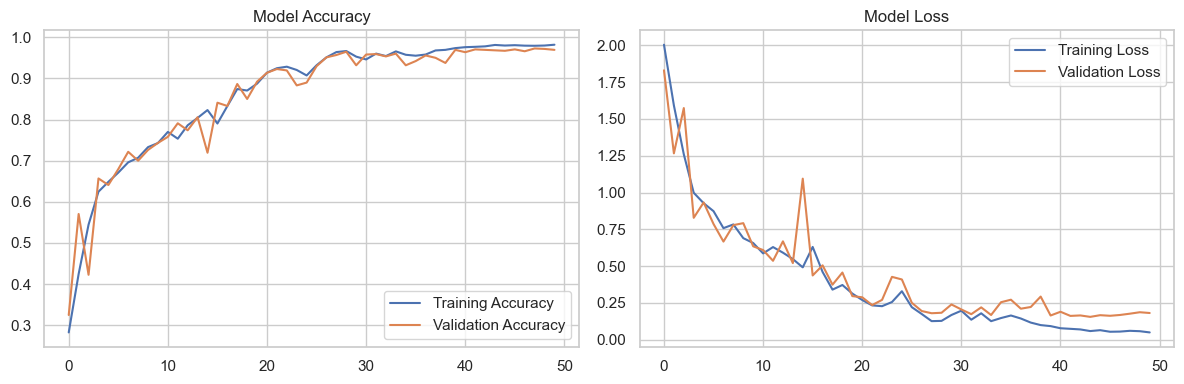

💾 Model saved as 'baby_cry_classifier_final.keras'
✅ Training complete! Ready for deployment! 🎉


In [23]:
# ==================== COMBINED SCRIPT: DATA PIPELINE + TRAINING ====================

import tensorflow as tf
import numpy as np
import pandas as pd
import librosa
import os
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ==================== CONFIGURATION ====================
BALANCED_DATASET_PATH = r"C:\Users\Hussein\Desktop\baby_cries_language\Baby_Dataset_BALANCED"
SAMPLE_RATE = 22050
DURATION = 5
MAX_LENGTH = SAMPLE_RATE * DURATION
N_MFCC = 40
INPUT_SHAPE = (40, 216, 1)
NUM_CLASSES = 11
BATCH_SIZE = 32
EPOCHS = 50
# =======================================================

# ==================== DATA PIPELINE FUNCTIONS ====================

def load_and_preprocess_audio(file_path):
    """Load audio file and convert to MFCC features"""
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        
        if len(y) > MAX_LENGTH:
            y = y[:MAX_LENGTH]
        else:
            y = np.pad(y, (0, max(0, MAX_LENGTH - len(y))), 'constant')
        
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=2048, hop_length=512)
        mfccs = np.expand_dims(mfccs, axis=-1)
        
        return mfccs
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def build_dataset_dataframe():
    """Create DataFrame with file paths and labels"""
    data = []
    label_to_id = {}
    
    classes = sorted(os.listdir(BALANCED_DATASET_PATH))
    label_to_id = {cls: i for i, cls in enumerate(classes)}
    
    for class_name in classes:
        class_path = os.path.join(BALANCED_DATASET_PATH, class_name)
        if os.path.isdir(class_path):
            for file in os.listdir(class_path):
                if file.endswith('.wav'):
                    data.append({
                        'file_path': os.path.join(class_path, file),
                        'label': label_to_id[class_name],
                        'label_name': class_name
                    })
    
    return pd.DataFrame(data), label_to_id

def create_tf_data_pipeline(df, batch_size=32, shuffle=True):
    """Create optimized tf.data pipeline"""
    
    def process_path(file_path, label):
        audio = tf.numpy_function(
            func=load_and_preprocess_audio,
            inp=[file_path],
            Tout=tf.float32
        )
        audio.set_shape((N_MFCC, 216, 1))
        return audio, label
    
    file_paths = tf.constant(df['file_path'].values)
    labels = tf.constant(df['label'].values)
    
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# ==================== MODEL ARCHITECTURE ====================

def create_cnn_lstm_model(input_shape, num_classes):
    """Create a hybrid CNN + LSTM model for audio classification"""
    
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Reshape((-1, 128)),
        tf.keras.layers.LSTM(128, return_sequences=True),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# ==================== MAIN EXECUTION ====================

print("🚀 Building dataset pipeline...")
print("Step 1: Creating file manifest...")

# Build DataFrame with all files
df, label_mapping = build_dataset_dataframe()
print(f"📊 Loaded {len(df)} samples")
print(f"🎯 Classes: {list(label_mapping.keys())}")

# Train/Test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f"📈 Training: {len(train_df)} samples, Testing: {len(test_df)} samples")

# Create tf.data pipelines
print("Step 2: Creating optimized data pipelines...")
train_dataset = create_tf_data_pipeline(train_df, batch_size=BATCH_SIZE, shuffle=True)
test_dataset = create_tf_data_pipeline(test_df, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Data pipelines created! Train batches: {len(list(train_dataset))}, Test batches: {len(list(test_dataset))}")

# Verify one batch
for X_batch, y_batch in train_dataset.take(1):
    print(f"📦 Batch shape: {X_batch.shape}, Labels shape: {y_batch.shape}")

# Save metadata
with open('label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

dataset_info = {
    'total_samples': len(df),
    'train_samples': len(train_df),
    'test_samples': len(test_df),
    'input_shape': (N_MFCC, 216, 1),
    'num_classes': len(label_mapping),
    'sample_rate': SAMPLE_RATE,
    'duration': DURATION
}

with open('dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=2)

print("💾 Metadata saved")

# ==================== TRAINING ====================

print("🚀 Creating model architecture...")
model = create_cnn_lstm_model(INPUT_SHAPE, NUM_CLASSES)
model.summary()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_baby_cry_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("🔥 Starting training...")
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=callbacks,
    verbose=1
)

# ==================== EVALUATION ====================

print("📊 Evaluating model...")
best_model = tf.keras.models.load_model('best_baby_cry_model.keras')
test_loss, test_accuracy = best_model.evaluate(test_dataset)
print(f"🎯 Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")

# Visualization
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

# Save final model
best_model.save('baby_cry_classifier_final.keras')
print("💾 Model saved as 'baby_cry_classifier_final.keras'")
print("✅ Training complete! Ready for deployment! 🎉")